# Evaluating a high-CO alert

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/classification/03-classification-metrics.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

In the previous notebook, we fitted a logistic-regression model that estimates the probability of a high-CO operating observation from turbine inlet temperature (TIT). A probability alone does not say whether the system should issue an alert. Here, we make that decision, compare it with held-out observations, and use a **confusion matrix** to describe what the model gets right and wrong.

We will use a training/validation/test split throughout. The model sees the training observations while it is fitted, validation data supports threshold decisions, and test observations remain untouched until the final evaluation.

## 1. Set aside training, validation, and test observations

Each row records one gas-turbine operating observation. The course-defined target `high_co` equals 1 when the measured carbon-monoxide concentration is at least 2 mg/m³, and 0 otherwise. We use TIT as one feature, as in the gradient-descent example.

Before fitting anything, we reserve 30% of the observations as a test set. We split the remaining observations into a training set and a validation set. `stratify=y` keeps the high-CO fraction approximately the same in every set. The model will fit on training data, threshold choices will use validation data, and the final confusion matrix will use the test set.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")

DATA_URL = "https://raw.githubusercontent.com/changyaochen/MECE4520/master/site/data/gas-turbine-course.csv"
candidates = [
    Path("../data/gas-turbine-course.csv"),
    Path("site/data/gas-turbine-course.csv"),
    Path("gas-turbine-course.csv"),
]
data_path = next((path for path in candidates if path.exists()), candidates[-1])

# In Google Colab, download the small course dataset if it is not already present.
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)

data = pd.read_csv(data_path)
model_data = data[["TIT", "high_co"]].dropna().copy()

X = model_data[["TIT"]]
y = model_data["high_co"]

X_development, X_test, y_development, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=4520,
    stratify=y,
)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_development,
    y_development,
    test_size=0.20,
    random_state=4520,
    stratify=y_development,
)

split_summary = pd.DataFrame(
    {
        "observations": [len(X_train), len(X_validation), len(X_test)],
        "high-CO fraction": [y_train.mean(), y_validation.mean(), y_test.mean()],
    },
    index=["Training set", "Validation set", "Test set"],
)
split_summary.style.format({"high-CO fraction": "{:.1%}"})


,observations,high-CO fraction
Training set,20570,38.8%
Validation set,5143,38.8%
Test set,11020,38.8%


## 2. Fit a probability model on the training set

We fit logistic regression only on the training observations. `predict_proba` then gives the estimated probability of a high-CO observation for each validation and test row.

For this notebook, we use scikit-learn's implementation rather than repeat the gradient-descent code from the previous notebook. The fitted model is the same type of logistic probability model.

In [2]:
model = LogisticRegression(max_iter=1_000)
model.fit(X_train, y_train)

validation_probabilities = model.predict_proba(X_validation)[:, 1]
test_probabilities = model.predict_proba(X_test)[:, 1]

print(f"Training observations used to fit the model: {len(X_train):,}")
print(f"Validation observations: {len(X_validation):,}")
print(f"Held-out test observations: {len(X_test):,}")
print(f"Fitted log-odds = {model.intercept_[0]:.3f} + ({model.coef_[0, 0]:.5f}) × TIT")


Training observations used to fit the model: 20,570
Validation observations: 5,143
Held-out test observations: 11,020
Fitted log-odds = 124.037 + (-0.11516) × TIT


## 3. Turn probabilities into high-CO alerts

Suppose the operating team adopts a pre-specified threshold of 0.50: issue a high-CO alert when the model's predicted probability is at least 0.50. This creates a predicted class:

$$
\hat{y}_i =
\begin{cases}
1, & \hat{p}_i \geq 0.50 \\\\ 
0, & \hat{p}_i < 0.50.
\end{cases}
$$

The threshold is a decision rule. It does not change the fitted probability model. The plot below shows how the test-set probabilities are distributed for observations that did and did not actually have high CO.

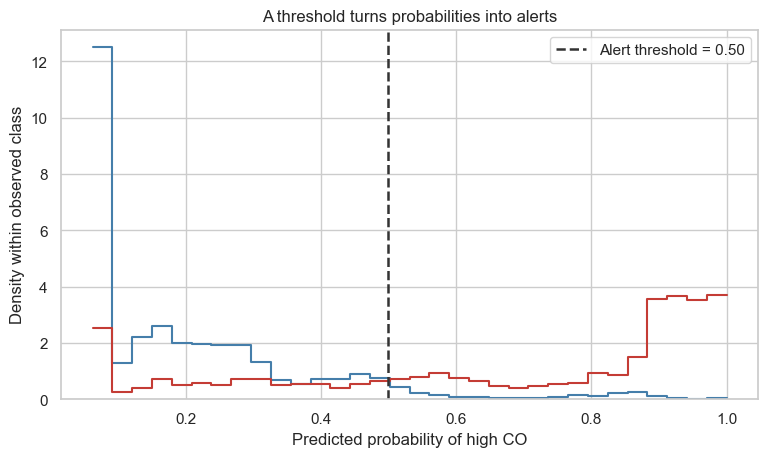

In [3]:
threshold = 0.50
test_predictions = (test_probabilities >= threshold).astype(int)

plot_frame = pd.DataFrame(
    {
        "Predicted high-CO probability": test_probabilities,
        "Observed class": np.where(y_test.to_numpy() == 1, "High CO", "Not high CO"),
    }
)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.histplot(
    data=plot_frame,
    x="Predicted high-CO probability",
    hue="Observed class",
    bins=32,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    palette={"Not high CO": "#457eaa", "High CO": "#c43c35"},
    ax=ax,
)
ax.axvline(threshold, color="#333333", linestyle="--", linewidth=1.8, label="Alert threshold = 0.50")
ax.set(
    xlabel="Predicted probability of high CO",
    ylabel="Density within observed class",
    title="A threshold turns probabilities into alerts",
)
ax.legend()
plt.show()


## 4. Read the confusion matrix

A confusion matrix compares the model's alert decision with the measured high-CO label on the test set. Each test observation belongs to exactly one cell:

| | Observed not high CO | Observed high CO |
|---|---:|---:|
| **No alert** | True negative (TN) | False negative (FN) |
| **Alert** | False positive (FP) | True positive (TP) |

A false negative misses a high-CO condition. A false positive issues an alert when the measured CO value was not high. Which mistake matters more depends on the operating context.

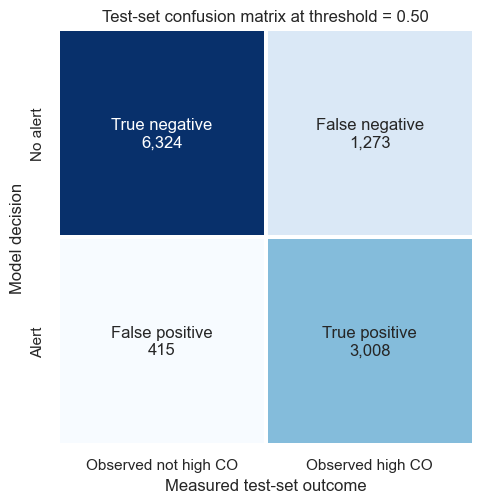

In [4]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, test_predictions, labels=[0, 1]).ravel()

matrix = np.array([[tn, fn], [fp, tp]])
cell_labels = np.array([
    [f"True negative\n{tn:,}", f"False negative\n{fn:,}"],
    [f"False positive\n{fp:,}", f"True positive\n{tp:,}"],
])

fig, ax = plt.subplots(figsize=(7.2, 5.4))
sns.heatmap(
    matrix,
    annot=cell_labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    square=True,
    linewidths=1.5,
    linecolor="white",
    xticklabels=["Observed not high CO", "Observed high CO"],
    yticklabels=["No alert", "Alert"],
    ax=ax,
)
ax.set(
    xlabel="Measured test-set outcome",
    ylabel="Model decision",
    title=f"Test-set confusion matrix at threshold = {threshold:.2f}",
)
plt.show()


## 5. Summarize performance with three metrics

The four counts measure different kinds of success and error. Three common summaries are:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

Accuracy asks how often the alert decision is correct overall. Precision asks, "When the model issues an alert, how often is high CO actually present?" Recall asks, "Of all high-CO observations, how many did the model alert on?"

In [5]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)

metrics = pd.DataFrame(
    {
        "value": [accuracy, precision, recall],
        "plain-language question": [
            "How often is the alert decision correct overall?",
            "When there is an alert, how often is CO actually high?",
            "Of the high-CO observations, how many receive an alert?",
        ],
    },
    index=["Accuracy", "Precision", "Recall"],
)
metrics.style.format({"value": "{:.1%}"})


,value,plain-language question
Accuracy,84.7%,How often is the alert decision correct overall?
Precision,87.9%,"When there is an alert, how often is CO actually high?"
Recall,70.3%,"Of the high-CO observations, how many receive an alert?"


## 6. A different threshold changes the tradeoff

The fitted probabilities stay fixed, but a lower threshold issues more alerts and a higher threshold issues fewer. This changes the balance between false positives and false negatives. Compare candidates on the validation set, choose a threshold using operating priorities, and then assess the selected rule once on the test set. The table below deliberately uses validation observations only.

The next classification material will turn this threshold sweep into an ROC curve and use AUC to summarize how well the model ranks high-CO observations above other observations.

In [6]:
def metrics_at_threshold(
    probabilities: np.ndarray, labels: pd.Series, threshold: float
) -> dict[str, float]:
    """Calculate classification metrics at one alert threshold.

    Args:
        probabilities: Predicted high-CO probabilities.
        labels: Observed high-CO labels for the same observations.
        threshold: Probability at or above which the model issues an alert.

    Returns:
        A dictionary containing the threshold, accuracy, precision, and recall.
    """
    predictions = (probabilities >= threshold).astype(int)
    current_tn, current_fp, current_fn, current_tp = confusion_matrix(
        labels, predictions, labels=[0, 1]
    ).ravel()
    return {
        "threshold": threshold,
        "accuracy": (current_tp + current_tn) / len(labels),
        "precision": current_tp / (current_tp + current_fp),
        "recall": current_tp / (current_tp + current_fn),
    }

validation_threshold_comparison = pd.DataFrame(
    [
        metrics_at_threshold(validation_probabilities, y_validation, value)
        for value in [0.25, 0.50, 0.75]
    ]
)
validation_threshold_comparison.style.format(
    {"threshold": "{:.2f}", "accuracy": "{:.1%}", "precision": "{:.1%}", "recall": "{:.1%}"}
)


,threshold,accuracy,precision,recall
0,0.25,74.1%,62.1%,85.4%
1,0.50,84.2%,86.7%,70.0%
2,0.75,81.0%,93.1%,55.2%


## Try it

Choose a threshold that would make sense if missing a high-CO observation were more costly than issuing an unnecessary alert. Run the starter code and compare its precision and recall with the 0.50 rule.

[← Return to Classification](index.qmd)

In [7]:
# Try a lower threshold to prioritize recall.
# metrics_at_threshold(validation_probabilities, y_validation, 0.35)
